<a href="https://colab.research.google.com/github/fdac25/MP2/blob/main/Vis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt



In [2]:
df = pd.read_csv("cliddel2_project_summary.csv", sep=";")
df.columns = ['project','commit','author','time','message']
df['Month'] = pd.to_datetime(df['time'], unit='s').dt.strftime('%Y-%m')
df.head()

,project,commit,author,time,message,Month
0,bids-apps_mrtrix3_connectome,025c9e88da8b55a057d97794f0d4199bd92cd13e,Robert Smith <robert.smith@florey.edu.au>,1761691205,Major refactoring to match future MRtrix 3.1.0...,2025-10
1,bids-apps_mrtrix3_connectome,02605b042612fd1d44665bdc841f039aefc36eab,Robert Smith <robert.smith@florey.edu.au>,1587289012,Modifications to better handle monopolar DWIs\...,2020-04
2,bids-apps_mrtrix3_connectome,034c5059440067e0f0e1c4910c848d9a7aad26fd,Robert Smith <robert.smith@florey.edu.au>,1693487594,Make DWI import robust to additional dots in f...,2023-08
3,bids-apps_mrtrix3_connectome,036f3991903333f84b4ba6a3e92030d16e4315d9,Robert Smith <robert.smith@florey.edu.au>,1604554387,Merge pull request #87 from BIDS-Apps/recipe_u...,2020-11
4,bids-apps_mrtrix3_connectome,0376c1c1e3399ae548f0bba2553edcd2fa34bb4e,Robert Smith <robert.smith@florey.edu.au>,1570060844,Increment internal version file to 0.5.0\n,2019-10


In [24]:
# project_list = ['bids-apps_mrtrix3_connectome', 'leakec_tfc', 'voutcn_megahit', 'moble_quaternion', 'santandermetgroup_downscaler', 'rajeshrinet_pyross', 'google_jax-md', 'ncar_wrf-python', 'juliaintervals_intervalarithmetic.jl', 'magazino_move_base_flex']
prj='magazino_move_base_flex'
df1 = df[df['project']==prj]
df2 = df1.groupby('Month').size().reset_index(name='Commits')
monthly_counts = df2
monthly_counts['time'] = pd.to_datetime(monthly_counts['Month'])
full_date_range = pd.DataFrame({'time': pd.date_range(start=monthly_counts['time'].min(), end=monthly_counts['time'].max(), freq='MS')})
monthly_counts = pd.merge(full_date_range, monthly_counts, on='time', how='left').fillna(0)
monthly_counts['Month'] = monthly_counts['time'].dt.strftime('%Y-%m')
commits_timeseries = monthly_counts[['Month', 'Commits']].copy()
commits_timeseries = commits_timeseries.rename(columns={'Commits': '#Commits'})
commits_timeseries.to_csv(
    f'cliddel2_commits_timeseries_{prj}.csv',
    sep=';',
    index=False
)
commits_timeseries.head()


,Month,#Commits
0,2017-06,8.0
1,2017-07,10.0
2,2017-08,4.0
3,2017-09,3.0
4,2017-10,14.0


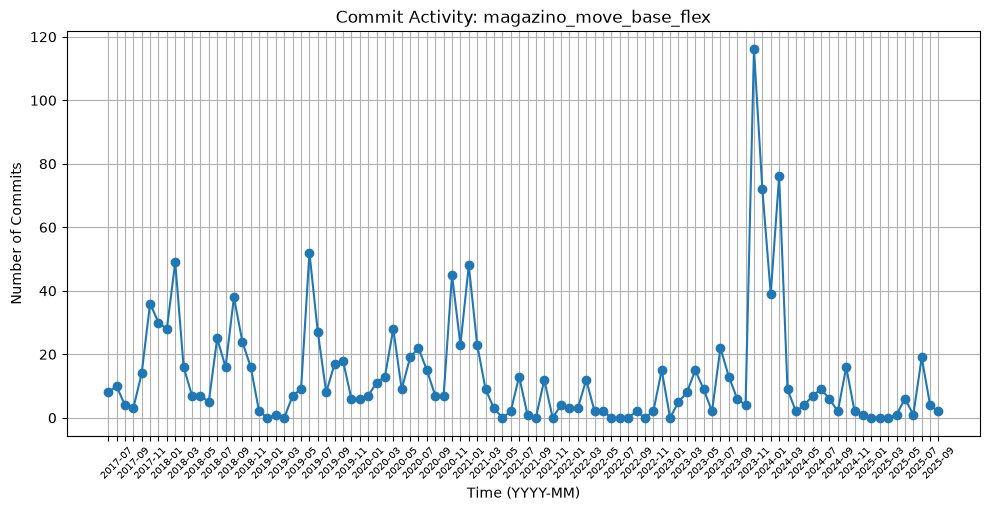

In [25]:
# Plot
import matplotlib.ticker as ticker

plt.figure(figsize=(10,5))
plt.plot(monthly_counts["Month"], monthly_counts["Commits"], marker="o", linestyle="-")
plt.xlabel("Time (YYYY-MM)")
plt.ylabel("Number of Commits")
plt.title("Commit Activity: "+prj)
plt.grid(True)
plt.tight_layout()
ax =  plt.gca()
for label in ax.xaxis.get_ticklabels()[::2]:
    label.set_visible(False)
plt.xticks(rotation=45, fontsize=7)
plt.savefig("cliddel2_timeseries_"+prj+".png", dpi=600)
plt.show()
plt.close()

In [26]:
# Build project statistics from each project's complete monthly timeline.
from urllib.parse import urlparse
from urllib.request import Request, urlopen
import json


def github_stats(repository_url):
    """Return stars, forks, and the date of the latest GitHub commit."""
    repository = urlparse(repository_url).path.strip('/').split('/')
    api_url = f"https://api.github.com/repos/{repository[0]}/{repository[1]}"
    request = Request(api_url, headers={'Accept': 'application/vnd.github+json'})
    try:
        with urlopen(request, timeout=10) as response:
            repository_data = json.load(response)
        commits_url = f"{api_url}/commits?per_page=1"
        with urlopen(Request(commits_url, headers={'Accept': 'application/vnd.github+json'}), timeout=10) as response:
            latest_commit = json.load(response)[0]
        commit_date = latest_commit['commit']['author']['date'][:10].replace('-', '/')
        return repository_data.get('stargazers_count'), repository_data.get('forks_count'), commit_date
    except Exception:
        return None, None, None


project_urls = pd.read_csv('net2prj.csv').set_index('WoC')['GH'].to_dict()
project_stats = []

for project, project_df in df.groupby('project'):
    project_df = project_df.copy()
    project_df['MonthPeriod'] = pd.to_datetime(project_df['time'], unit='s').dt.to_period('M')
    monthly = project_df.groupby('MonthPeriod').size()
    timeline = monthly.reindex(
        pd.period_range(monthly.index.min(), monthly.index.max(), freq='M'),
        fill_value=0
    )

    zero_runs = []
    run_start = None
    for month, commit_count in timeline.items():
        if commit_count == 0 and run_start is None:
            run_start = month
        elif commit_count != 0 and run_start is not None:
            zero_runs.append((run_start, month - 1, (month - run_start).n))
            run_start = None
    if run_start is not None:
        end_month = timeline.index.max()
        zero_runs.append((run_start, end_month, (end_month - run_start).n + 1))

    longest_gap = max(zero_runs, key=lambda gap: gap[2]) if zero_runs else None
    stars, forks, last_github_commit = github_stats(project_urls[project])
    project_stats.append({
        'project': project,
        '#commits': len(project_df),
        '#authors': project_df['author'].nunique(),
        'From': int(project_df['time'].min()),
        'To': int(project_df['time'].max()),
        '#stars': stars,
        '#forks': forks,
        'LastGHCommitDate': last_github_commit,
        'LongestGapStart (YYYY-MM)': longest_gap[0].strftime('%Y-%m') if longest_gap else '',
        'LongestGapEnd (YYYY-MM)': longest_gap[1].strftime('%Y-%m') if longest_gap else '',
        'LongestGapLength': longest_gap[2] if longest_gap else 0,
        'NumCommitsAfterLastGap': int(
            project_df['MonthPeriod'].gt(longest_gap[1]).sum()
        ) if longest_gap else 0,
        'NumberOfGapsInTimeline': sum(gap[2] >= 3 for gap in zero_runs),
        'ActivityPattern': ''
    })

project_stats = pd.DataFrame(project_stats)
project_stats.to_csv('cliddel2_project_stats.csv', sep=';', index=False)
project_stats

,project,#commits,#authors,From,To,#stars,#forks,LastGHCommitDate,LongestGapStart (YYYY-MM),LongestGapEnd (YYYY-MM),LongestGapLength,NumCommitsAfterLastGap,NumberOfGapsInTimeline,ActivityPattern
0,bids-apps_mrtrix3_connectome,472,12,1470327983,1773795736,55,28,2025/06/19,2023-11,2025-05,19,25,8,
1,google_jax-md,1416,83,1557850490,1762560185,1463,251,2026/08/18,2019-07,2019-07,1,1344,0,
2,juliaintervals_intervalarithmetic.jl,3403,105,1395244712,1776137504,330,71,2026/09/10,2014-12,2015-03,4,3219,2,
3,leakec_tfc,765,6,1601671504,1758199663,47,13,2026/08/01,2024-05,2024-08,4,101,1,
4,magazino_move_base_flex,1329,80,1498233087,1757155217,549,183,2026/09/21,2022-06,2022-08,3,497,2,
5,moble_quaternion,1064,45,1310767115,1761608346,659,92,2025/11/24,2011-08,2014-02,31,1060,6,
6,ncar_wrf-python,844,39,1449091912,1776166179,500,178,2026/08/03,2019-07,2020-07,13,362,5,
7,rajeshrinet_pyross,2269,35,1584976412,1725115770,167,56,2024/08/31,2023-08,2024-07,12,6,4,
8,santandermetgroup_downscaler,1141,25,1382708378,1742771983,112,62,2025/03/11,2024-02,2024-10,9,4,7,
9,voutcn_megahit,738,35,1411640958,1761624424,727,145,2025/10/28,2020-01,2022-02,26,30,8,


# Identify the Longest Inactivity Gap

2022-02 to 2023-04

Add all that info to netid_project_stats.csv